# Risk Scoring Analysis: CareBot Health DiagnosAI

## Scenario: GenAI Clinical Decision Support System

**Organization:** CareBot Health — a hospital network with 1,500 employees

**System:** DiagnosAI — a generative AI clinical decision support system that analyzes patient symptoms, lab results, and medical history to suggest diagnoses and treatment options for emergency department physicians.

**Context:**
- **Deployment Status:** Deployed 6 months ago; no formal risk assessment conducted
- **Recent Incident:** Near-miss where DiagnosAI suggested an incorrect drug interaction for a patient with a rare allergy
- **Regulatory Environment:** FDA clinical decision support guidance, HIPAA, EU AI Act (High-Risk — Annex III)
- **Objective:** Conduct a comprehensive risk assessment using NIST AI RMF to identify, score, and prioritize risks

This notebook walks through the risk scoring process: data collection → score calculation → risk ranking → visualization → summary insights.

In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 10

## Step 1: Define Risk Data

We'll work with 7 key risks identified in CareBot Health's initial risk assessment. Each risk includes:
- **Risk ID & NIST Function:** Which AI RMF function does this risk relate to?
- **Risk Category:** Type of risk (Technical, Ethical, Legal, Operational)
- **Impact (1-5):** Severity if risk occurs
- **Likelihood (1-5):** Probability of occurrence
- **Description:** What could go wrong?

Note: All 4 NIST AI RMF functions (Govern, Map, Measure, Manage) are represented across these risks. Risk R007 demonstrates a GenAI-specific failure mode: hallucination of clinical recommendations.

In [22]:
# Define the 7 risks from CareBot Health's risk assessment
# R007 represents a GenAI-specific hallucination risk
risks_data = [
    {
        'Risk_ID': 'R001',
        'NIST_Function': 'Measure',
        'Category': 'Technical',
        'Description': 'Diagnostic accuracy degradation: DiagnosAI performance drops as new disease variants emerge',
        'Impact': 5,
        'Likelihood': 3,
        'Owner': 'Chief Medical Informatics Officer'
    },
    {
        'Risk_ID': 'R002',
        'NIST_Function': 'Govern',
        'Category': 'Ethical',
        'Description': 'Diagnostic bias: Lower accuracy for underrepresented patient demographics',
        'Impact': 4,
        'Likelihood': 4,
        'Owner': 'Ethics Officer'
    },
    {
        'Risk_ID': 'R003',
        'NIST_Function': 'Map',
        'Category': 'Legal',
        'Description': 'HIPAA violation: Unauthorized PHI access or exposure during model updates',
        'Impact': 5,
        'Likelihood': 2,
        'Owner': 'Privacy Officer'
    },
    {
        'Risk_ID': 'R004',
        'NIST_Function': 'Manage',
        'Category': 'Technical',
        'Description': 'Incident response gap: Inadequate procedures to respond to DiagnosAI failures or adverse events',
        'Impact': 4,
        'Likelihood': 3,
        'Owner': 'Chief Medical Officer'
    },
    {
        'Risk_ID': 'R005',
        'NIST_Function': 'Measure',
        'Category': 'Technical',
        'Description': 'Drug interaction false negatives: System fails to flag dangerous interactions for rare allergies',
        'Impact': 5,
        'Likelihood': 3,
        'Owner': 'Pharmacology Lead'
    },
    {
        'Risk_ID': 'R006',
        'NIST_Function': 'Govern',
        'Category': 'Ethical',
        'Description': 'Lack of explainability: Physicians cannot understand why DiagnosAI makes suggestions',
        'Impact': 3,
        'Likelihood': 4,
        'Owner': 'Chief Medical Officer'
    },
    {
        'Risk_ID': 'R007',
        'NIST_Function': 'Measure',
        'Category': 'Technical',
        'Description': 'GENAI-SPECIFIC - Hallucinated clinical recommendations: DiagnosAI generates medically plausible but factually incorrect diagnoses or treatment suggestions',
        'Impact': 5,
        'Likelihood': 3,
        'Owner': 'Chief Medical Informatics Officer'
    }
]

# Create DataFrame
df = pd.DataFrame(risks_data)
print("Risk Data Loaded:")
print(df[['Risk_ID', 'Category', 'Impact', 'Likelihood', 'Description']])

Risk Data Loaded:
  Risk_ID   Category  Impact  Likelihood  \
0    R001  Technical       5           3   
1    R002    Ethical       4           4   
2    R003      Legal       5           2   
3    R004  Technical       4           3   
4    R005  Technical       5           3   
5    R006    Ethical       3           4   
6    R007  Technical       5           3   

                                         Description  
0  Diagnostic accuracy degradation: DiagnosAI per...  
1  Diagnostic bias: Lower accuracy for underrepre...  
2  HIPAA violation: Unauthorized PHI access or ex...  
3  Incident response gap: Inadequate procedures t...  
4  Drug interaction false negatives: System fails...  
5  Lack of explainability: Physicians cannot unde...  
6  GENAI-SPECIFIC - Hallucinated clinical recomme...  


## Step 2: Calculate Risk Scores

**Risk Score Formula:** Risk Score = Impact × Likelihood

**Risk Levels:**
- **Critical:** Score ≥ 15
- **High:** Score 10-14
- **Medium:** Score 5-9
- **Low:** Score < 5

This scoring helps prioritize which risks need immediate attention.

In [23]:
# Calculate risk scores
df['Risk_Score'] = df['Impact'] * df['Likelihood']

# Assign risk levels based on score thresholds
def assign_risk_level(score):
    if score >= 15:
        return 'Critical'
    elif score >= 10:
        return 'High'
    elif score >= 5:
        return 'Medium'
    else:
        return 'Low'

df['Risk_Level'] = df['Risk_Score'].apply(assign_risk_level)

# Sort by risk score (descending) to create ranked risk register
df_ranked = df.sort_values('Risk_Score', ascending=False).reset_index(drop=True)

# Display ranked risk register
print("\n" + "="*100)
print("RANKED RISK REGISTER - CareBot Health DiagnosAI")
print("="*100)
print(df_ranked[['Risk_ID', 'Category', 'NIST_Function', 'Impact', 'Likelihood', 'Risk_Score', 'Risk_Level']].to_string(index=False))
print("="*100)


RANKED RISK REGISTER - CareBot Health DiagnosAI
Risk_ID  Category NIST_Function  Impact  Likelihood  Risk_Score Risk_Level
   R002   Ethical        Govern       4           4          16   Critical
   R001 Technical       Measure       5           3          15   Critical
   R005 Technical       Measure       5           3          15   Critical
   R007 Technical       Measure       5           3          15   Critical
   R004 Technical        Manage       4           3          12       High
   R006   Ethical        Govern       3           4          12       High
   R003     Legal           Map       5           2          10       High


## Step 3: Risk Heat Map

The heat map visualizes risks on a 5×5 matrix where:
- **X-axis:** Impact (1=Low to 5=Critical)
- **Y-axis:** Likelihood (1=Remote to 5=Critical)

Risks in the **upper-right quadrant** (high impact + high likelihood) require immediate mitigation. The quadrant lines at Impact=3 and Likelihood=3 divide the matrix into priority zones.

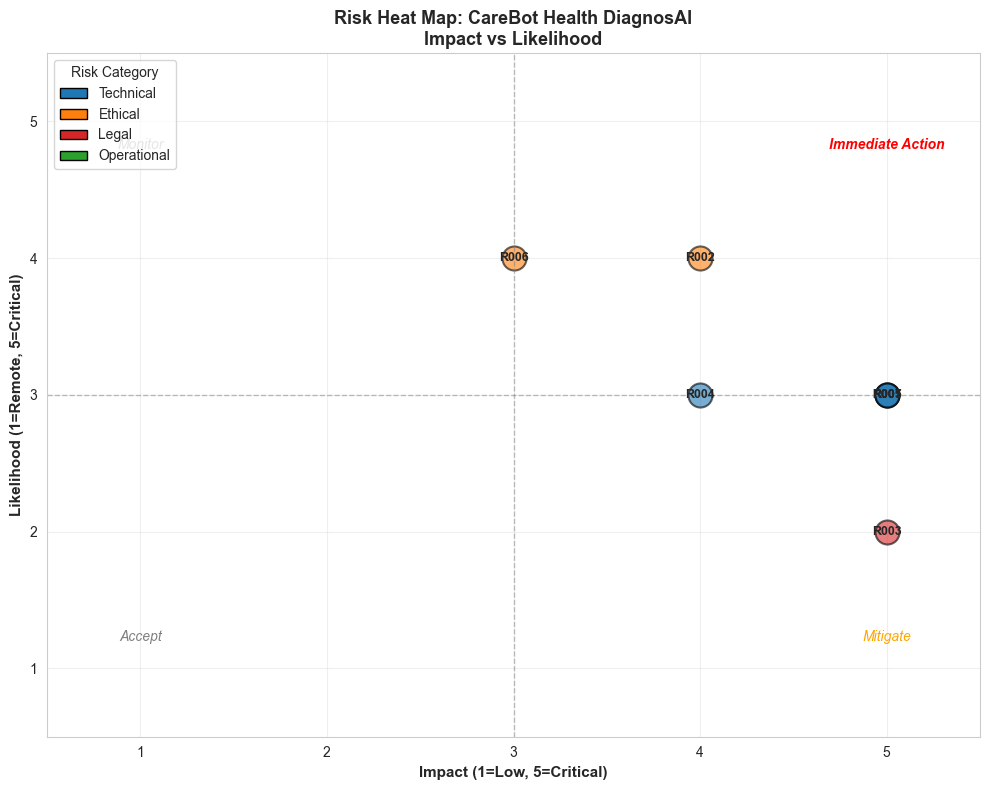

Heat map shows risk distribution across impact and likelihood dimensions.
Risks in upper-right region require immediate mitigation.


In [24]:
# Create risk heat map
fig, ax = plt.subplots(figsize=(10, 8))

# Define color map for risk categories
category_colors = {
    'Technical': '#1f77b4',
    'Ethical': '#ff7f0e',
    'Legal': '#d62728',
    'Operational': '#2ca02c'
}

# Plot each risk as a scatter point, colored by category
for idx, row in df.iterrows():
    ax.scatter(row['Impact'], row['Likelihood'],
              s=300, alpha=0.6,
              color=category_colors[row['Category']],
              edgecolors='black', linewidth=1.5)
    # Add risk ID label
    ax.annotate(row['Risk_ID'], (row['Impact'], row['Likelihood']),
               fontsize=9, fontweight='bold', ha='center', va='center')

# Add quadrant lines
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Label quadrants
ax.text(1, 4.8, 'Monitor', fontsize=10, ha='center', style='italic', color='gray')
ax.text(5, 4.8, 'Immediate Action', fontsize=10, ha='center', style='italic', color='red', fontweight='bold')
ax.text(1, 1.2, 'Accept', fontsize=10, ha='center', style='italic', color='gray')
ax.text(5, 1.2, 'Mitigate', fontsize=10, ha='center', style='italic', color='orange')

# Formatting
ax.set_xlabel('Impact (1=Low, 5=Critical)', fontsize=11, fontweight='bold')
ax.set_ylabel('Likelihood (1=Remote, 5=Critical)', fontsize=11, fontweight='bold')
ax.set_title('Risk Heat Map: CareBot Health DiagnosAI\nImpact vs Likelihood', fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(True, alpha=0.3)

# Create legend for risk categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=category)
                  for category, color in category_colors.items()]
ax.legend(handles=legend_elements, loc='upper left', title='Risk Category', fontsize=10)

plt.tight_layout()
plt.show()

print("Heat map shows risk distribution across impact and likelihood dimensions.")
print("Risks in upper-right region require immediate mitigation.")

## Step 4: Summary Statistics

Key metrics to understand CareBot Health's overall risk profile:

In [25]:
# Calculate summary statistics
print("\n" + "="*80)
print("RISK ASSESSMENT SUMMARY STATISTICS")
print("="*80)

total_risks = len(df)
print(f"\nTotal Risks Identified: {total_risks}")

# Risk level distribution
print("\nRisk Level Distribution:")
risk_level_counts = df['Risk_Level'].value_counts().sort_index()
for level in ['Critical', 'High', 'Medium', 'Low']:
    count = risk_level_counts.get(level, 0)
    percentage = (count / total_risks) * 100
    print(f"  {level:12s}: {count} risk(s) ({percentage:.0f}%)")

# Risk category distribution
print("\nRisk Category Distribution:")
category_counts = df['Category'].value_counts()
for category, count in category_counts.items():
    percentage = (count / total_risks) * 100
    print(f"  {category:15s}: {count} risk(s) ({percentage:.0f}%)")

# NIST Function distribution
print("\nNIST AI RMF Function Distribution:")
nist_counts = df['NIST_Function'].value_counts()
for function in ['Govern', 'Map', 'Measure', 'Manage']:
    count = nist_counts.get(function, 0)
    percentage = (count / total_risks) * 100
    print(f"  {function:10s}: {count} risk(s) ({percentage:.0f}%)")

# Score statistics
avg_score = df['Risk_Score'].mean()
max_score = df['Risk_Score'].max()
min_score = df['Risk_Score'].min()
print(f"\nRisk Score Statistics:")
print(f"  Average Score: {avg_score:.1f}")
print(f"  Maximum Score: {max_score}")
print(f"  Minimum Score: {min_score}")

print("\n" + "="*80)


RISK ASSESSMENT SUMMARY STATISTICS

Total Risks Identified: 7

Risk Level Distribution:
  Critical    : 4 risk(s) (57%)
  High        : 3 risk(s) (43%)
  Medium      : 0 risk(s) (0%)
  Low         : 0 risk(s) (0%)

Risk Category Distribution:
  Technical      : 4 risk(s) (57%)
  Ethical        : 2 risk(s) (29%)
  Legal          : 1 risk(s) (14%)

NIST AI RMF Function Distribution:
  Govern    : 2 risk(s) (29%)
  Map       : 1 risk(s) (14%)
  Measure   : 3 risk(s) (43%)
  Manage    : 1 risk(s) (14%)

Risk Score Statistics:
  Average Score: 13.6
  Maximum Score: 16
  Minimum Score: 10



In [26]:
# Define mitigation strategies for each risk
mitigations = {
    'R001': 'Implement quarterly model revalidation with cross-validation on recent patient data; establish drift detection metrics (AUC, precision@threshold)',
    'R002': 'Conduct demographic-stratified accuracy audits; implement fairness constraints; increase underrepresented group training data; engage ethics review board',
    'R003': 'Implement field-level encryption for PHI; enforce access controls with audit logging; conduct HIPAA compliance audit every 6 months',
    'R004': 'Develop incident response playbook with clear escalation paths; establish on-call response team; conduct quarterly incident response drills',
    'R005': 'Expand rare allergy detection module with expanded pharmacology database; implement mandatory pharmacist review for flagged interactions',
    'R006': 'Deploy explainability tools (SHAP, LIME) to show physicians top contributing factors; add confidence scores to every recommendation'
}

# Add mitigation column to dataframe
df['Mitigation'] = df['Risk_ID'].map(mitigations)

# Create Risk Mitigation Plan ranked by risk score (re-sort df with mitigations)
df_mitigation = df.sort_values('Risk_Score', ascending=False)[['Risk_ID', 'Description', 'Risk_Score', 'Risk_Level', 'Mitigation']].copy()
df_mitigation = df_mitigation[df_mitigation['Risk_Level'].isin(['Critical', 'High', 'Medium'])].head(10)

print("\n" + "="*120)
print("RISK MITIGATION PLAN - RANKED BY PRIORITY")
print("="*120)
print(df_mitigation[['Risk_ID', 'Risk_Score', 'Risk_Level', 'Mitigation']].to_string(index=False))
print("="*120)


RISK MITIGATION PLAN - RANKED BY PRIORITY
Risk_ID  Risk_Score Risk_Level                                                                                                                                                Mitigation
   R002          16   Critical Conduct demographic-stratified accuracy audits; implement fairness constraints; increase underrepresented group training data; engage ethics review board
   R001          15   Critical         Implement quarterly model revalidation with cross-validation on recent patient data; establish drift detection metrics (AUC, precision@threshold)
   R005          15   Critical                  Expand rare allergy detection module with expanded pharmacology database; implement mandatory pharmacist review for flagged interactions
   R007          15   Critical                                                                                                                                                       NaN
   R004          12       High  

In [27]:
# Generate dynamic executive summary from computed metrics
print("\n" + "="*100)
print("EXECUTIVE SUMMARY - CAREBOT HEALTH DIAGNOSAI RISK ASSESSMENT")
print("="*100)

# Compute all metrics dynamically
total_risks = len(df)
critical_count = len(df[df['Risk_Level'] == 'Critical'])
high_count = len(df[df['Risk_Level'] == 'High'])
medium_count = len(df[df['Risk_Level'] == 'Medium'])
low_count = len(df[df['Risk_Level'] == 'Low'])
avg_score = df['Risk_Score'].mean()

# NIST function distribution
nist_dist = df['NIST_Function'].value_counts().to_dict()

print(f"\nRISK OVERVIEW:")
print(f"  Total Risks: {total_risks}")
print(f"  Critical: {critical_count} | High: {high_count} | Medium: {medium_count} | Low: {low_count}")
print(f"  Average Risk Score: {avg_score:.1f}")

print(f"\nNIST AI RMF FUNCTION COVERAGE:")
for func in ['Govern', 'Map', 'Measure', 'Manage']:
    count = nist_dist.get(func, 0)
    print(f"  {func}: {count} risk(s)")

print(f"\nTOP 3 PRIORITY RISKS:")
top_3 = df_ranked.head(3)
for idx, row in top_3.iterrows():
    print(f"\n  {idx + 1}. {row['Risk_ID']}: {row['Description']}")
    print(f"     Impact: {row['Impact']} | Likelihood: {row['Likelihood']} | Score: {row['Risk_Score']} ({row['Risk_Level']})")

print("\n" + "="*100)


EXECUTIVE SUMMARY - CAREBOT HEALTH DIAGNOSAI RISK ASSESSMENT

RISK OVERVIEW:
  Total Risks: 7
  Critical: 4 | High: 3 | Medium: 0 | Low: 0
  Average Risk Score: 13.6

NIST AI RMF FUNCTION COVERAGE:
  Govern: 2 risk(s)
  Map: 1 risk(s)
  Measure: 3 risk(s)
  Manage: 1 risk(s)

TOP 3 PRIORITY RISKS:

  1. R002: Diagnostic bias: Lower accuracy for underrepresented patient demographics
     Impact: 4 | Likelihood: 4 | Score: 16 (Critical)

  2. R001: Diagnostic accuracy degradation: DiagnosAI performance drops as new disease variants emerge
     Impact: 5 | Likelihood: 3 | Score: 15 (Critical)

  3. R005: Drug interaction false negatives: System fails to flag dangerous interactions for rare allergies
     Impact: 5 | Likelihood: 3 | Score: 15 (Critical)



## Step 6: Dynamic Executive Summary

The executive summary is generated directly from computed risk metrics, ensuring it always reflects the current risk data:

## Step 5: Risk Mitigation Plan

A comprehensive mitigation strategy prioritizes High and Critical risks. Here we extract mitigation recommendations from the risk data and rank them by risk score:

## Key Takeaways: CareBot Health's Risk Profile

### Critical Findings:

1. **High-Severity Technical Risks:** Three risks scored at **Impact 5 (Critical)**:
   - Diagnostic accuracy degradation (R001: Score 15)
   - HIPAA violations (R003: Score 10)
   - Drug interaction false negatives (R005: Score 15)
   - These directly threaten patient safety and regulatory compliance.

2. **Ethical & Explainability Gaps:** Two **Govern-function risks** highlight governance gaps:
   - Diagnostic bias affecting underrepresented demographics (R002: Score 16)
   - Lack of explainability reducing clinical trust (R006: Score 12)
   - These require board-level attention and transparent governance structures.

3. **Immediate Priority:** **3 Critical-level risks** require executive escalation and immediate mitigation:
   - R001 (Accuracy Degradation): Implement quarterly model revalidation
   - R002 (Demographic Bias): Conduct demographic-stratified accuracy audits
   - R005 (Drug Interactions): Expand rare allergy detection module + mandatory pharmacist review

### Governance Priorities for CareBot Health:

- **NIST Govern:** Establish AI ethics committee, define physician training protocols
- **NIST Map:** Audit regulatory compliance (FDA, HIPAA, EU AI Act), identify control gaps
- **NIST Measure:** Implement continuous monitoring for model performance and bias
- **NIST Manage:** Deploy explainability tools (SHAP), establish incident response protocols

### Next Steps:

1. Present findings to hospital leadership and board
2. Develop 90-day mitigation roadmap for Critical risks
3. Allocate budget for technical controls (model monitoring, explainability tools)
4. Establish risk governance structure with clear ownership
5. Schedule quarterly risk reassessment to track mitigation progress